In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

y = np.where(y == 0, -1, 1)  # SVM expects -1 and +1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))

In [4]:
class KNN:
    def __init__(self, k=3, distance_metric="euclidean"):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _distance(self, x1, x2):
        if self.distance_metric == "euclidean":
            return euclidean_distance(x1, x2)
        else:
            return manhattan_distance(x1, x2)

    def predict(self, X):
        predictions = []

        for x in X:
            distances = [
                (self._distance(x, x_train), y_train)
                for x_train, y_train in zip(self.X_train, self.y_train)
            ]

            distances.sort(key=lambda x: x[0])
            k_nearest = distances[:self.k]

            labels = [label for _, label in k_nearest]
            prediction = Counter(labels).most_common(1)[0][0]
            predictions.append(prediction)

        return np.array(predictions)

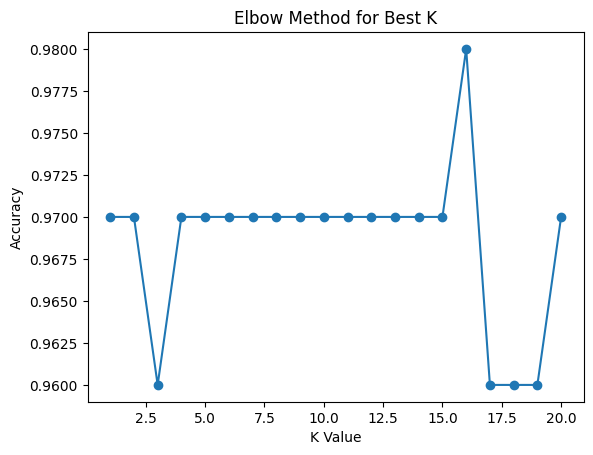

In [5]:
accuracies = []

k_values = range(1, 21)

for k in k_values:
    model = KNN(k=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = np.mean(preds == y_test)
    accuracies.append(acc)

plt.plot(k_values, accuracies, marker='o')
plt.title("Elbow Method for Best K")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.show()

In [6]:
knn = KNN(k=5)
knn.fit(X_train, y_train)
predictions_knn = knn.predict(X_test)

print("k-NN Accuracy:", np.mean(predictions_knn == y_test))

k-NN Accuracy: 0.97


In [7]:
def linear_kernel(x1, x2):
    return np.dot(x1, x2)

def polynomial_kernel(x1, x2, degree=3):
    return (1 + np.dot(x1, x2)) ** degree

def rbf_kernel(x1, x2, gamma=0.5):
    return np.exp(-gamma * np.linalg.norm(x1 - x2) ** 2)

In [8]:
class SVM:
    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000, kernel="linear"):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.kernel = kernel

    def _kernel(self, x1, x2):
        if self.kernel == "linear":
            return linear_kernel(x1, x2)
        elif self.kernel == "poly":
            return polynomial_kernel(x1, x2)
        else:
            return rbf_kernel(x1, x2)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y[idx] * (np.dot(x_i, self.w) + self.b) >= 1

                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (
                        2 * self.lambda_param * self.w - np.dot(x_i, y[idx])
                    )
                    self.b -= self.lr * y[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) + self.b
        return np.sign(approx)

In [9]:
svm = SVM(kernel="linear")
svm.fit(X_train, y_train)

predictions_svm = svm.predict(X_test)

print("SVM Accuracy:", np.mean(predictions_svm == y_test))

SVM Accuracy: 0.5


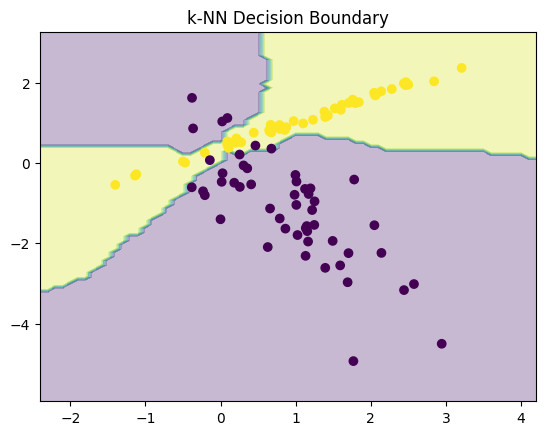

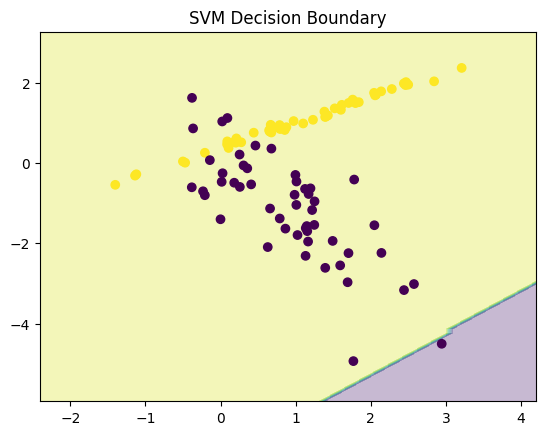

In [10]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.1),
        np.arange(y_min, y_max, 0.1)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid)
    preds = preds.reshape(xx.shape)

    plt.contourf(xx, yy, preds, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title(title)
    plt.show()

plot_decision_boundary(knn, X_test, y_test, "k-NN Decision Boundary")
plot_decision_boundary(svm, X_test, y_test, "SVM Decision Boundary")